In [ ]:
records = ['100', '101', '103', '105']

In [ ]:
!pip install wfdb

In [6]:
import wfdb

data = []

for rec in records:
    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    annotation = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

    data.append((record, annotation))
    print(len(data))

1
2
3
4


In [7]:
# Select one record (example: first one)
record, annotation = data[0]

signal = record.p_signal[:, 0]     # ECG signal
true_peaks = annotation.sample

In [8]:
from scipy.signal import savgol_filter

signal = savgol_filter(signal, 51, 3)

In [63]:
import numpy as np

signals_raw = []
signals_norm = []
annotations = []

for record, annotation in data:

    # Raw signal
    signal_raw = record.p_signal[:, 0]

    # Normalized signal
    signal_norm = (signal_raw - np.mean(signal_raw)) / np.std(signal_raw)

    # Store both
    signals_raw.append(signal_raw)
    signals_norm.append(signal_norm)
    annotations.append(annotation.sample)

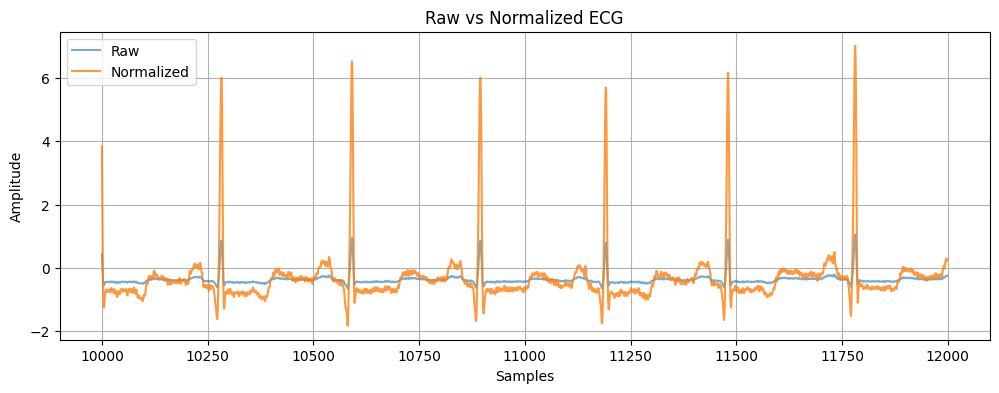

In [65]:
plt.figure(figsize=(12,4))

plt.plot(range(start, end), signal_raw[start:end], label="Raw", alpha=0.6)
plt.plot(range(start, end), signal_norm[start:end], label="Normalized", alpha=0.8)

plt.title("Raw vs Normalized ECG")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.show()

In [66]:
print(len(signals))
print(len(annotations))
print(signals[0].shape)

4
4
(650000,)


In [67]:
window_sizes = [150, 200, 250]# around 0.5 sec


In [68]:
for window_size in [150, 200, 250]:
    print(f"\nTesting window size: {window_size}")


Testing window size: 150

Testing window size: 200

Testing window size: 250


In [69]:
def calculate_heart_rate(peaks, fs=360):
    rr_intervals = np.diff(peaks) / fs
    heart_rate = 60 / np.mean(rr_intervals)
    return heart_rate

In [70]:
hr = calculate_heart_rate(true_peaks)
print(f"Heart Rate: {hr:.2f} BPM")

Heart Rate: 85.33 BPM


In [17]:
X = []
y = []

window_size = 200
half_window = window_size // 2

for signal, r_peaks in zip(signals, annotations):

    signal_length = len(signal)

    # Create label array
    labels = np.zeros(signal_length)

    # Mark R-peaks
    labels[r_peaks] = 1

    # Sliding window
    for i in range(half_window, signal_length - half_window):

        window = signal[i - half_window : i + half_window]
        label = labels[i]

        X.append(window)
        y.append(label)

In [18]:
X = np.array(X)
y = np.array(y)

# Get indices
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

# Balance (same number of negatives as positives)
neg_idx = np.random.choice(neg_idx, size=len(pos_idx), replace=False)

# Combine
final_idx = np.concatenate([pos_idx, neg_idx])

# Shuffle
np.random.shuffle(final_idx)

X = X[final_idx]
y = y[final_idx]

In [19]:
print(X.shape)
print(y.shape)
print("Positive:", np.sum(y))
print("Negative:", len(y) - np.sum(y))

(17846, 200)
(17846,)
Positive: 8923.0
Negative: 8923.0


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [22]:
X_train = X_train.unsqueeze(1)
X_val = X_val.unsqueeze(1)

In [23]:
X_train = X_train.permute(0, 2, 1)
X_val = X_val.permute(0, 2, 1)

In [27]:
X_train = X_train.permute(0, 2, 1).contiguous()
X_val = X_val.permute(0, 2, 1).contiguous()

In [28]:
print(X_train.shape)

torch.Size([14276, 200, 1])


In [29]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=128
)

In [30]:
for X_batch, _ in train_loader:
    print(X_batch.shape)
    break

torch.Size([128, 200, 1])



 Fold 1
Epoch 1 | Train: 0.6558 | Val: 0.5356
Epoch 2 | Train: 0.5288 | Val: 0.4775
Epoch 3 | Train: 0.4485 | Val: 0.4031
Epoch 4 | Train: 0.3608 | Val: 0.3029
Epoch 5 | Train: 0.2207 | Val: 0.2575
Epoch 6 | Train: 0.1888 | Val: 0.1784
Epoch 7 | Train: 0.1795 | Val: 0.2308
Epoch 8 | Train: 0.1564 | Val: 0.1402
Epoch 9 | Train: 0.1230 | Val: 0.1419
Epoch 10 | Train: 0.1236 | Val: 0.1184
Epoch 11 | Train: 0.1127 | Val: 0.1442
Epoch 12 | Train: 0.1148 | Val: 0.0971
Epoch 13 | Train: 0.1084 | Val: 0.1060
Epoch 14 | Train: 0.1164 | Val: 0.0990
Epoch 15 | Train: 0.1213 | Val: 0.0975
Epoch 16 | Train: 0.1038 | Val: 0.0946
Epoch 17 | Train: 0.0965 | Val: 0.0941
Epoch 18 | Train: 0.1166 | Val: 0.1054
Epoch 19 | Train: 0.0964 | Val: 0.0739
Epoch 20 | Train: 0.0983 | Val: 0.0769
Fold 1 → Precision: 0.9929, Recall: 0.9700, F1: 0.9813


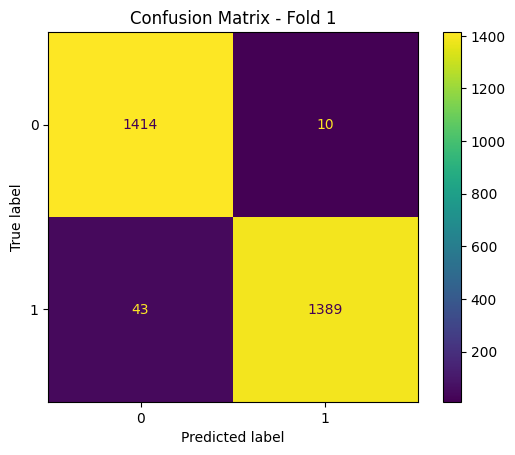


 Fold 2
Epoch 1 | Train: 0.6727 | Val: 0.6199
Epoch 2 | Train: 0.5352 | Val: 0.4336
Epoch 3 | Train: 0.5531 | Val: 0.5595
Epoch 4 | Train: 0.4706 | Val: 0.4360
Epoch 5 | Train: 0.4777 | Val: 0.4279
Epoch 6 | Train: 0.3913 | Val: 0.3230
Epoch 7 | Train: 0.3446 | Val: 0.3208
Epoch 8 | Train: 0.4849 | Val: 0.5341
Epoch 9 | Train: 0.5129 | Val: 0.4302
Epoch 10 | Train: 0.3779 | Val: 0.2971
Epoch 11 | Train: 0.2945 | Val: 0.2400
Epoch 12 | Train: 0.3067 | Val: 0.2553
Epoch 13 | Train: 0.2677 | Val: 0.2272
Epoch 14 | Train: 0.2473 | Val: 0.2080
Epoch 15 | Train: 0.2167 | Val: 0.1816
Epoch 16 | Train: 0.2036 | Val: 0.1754
Epoch 17 | Train: 0.1757 | Val: 0.1352
Epoch 18 | Train: 0.1788 | Val: 0.1270
Epoch 19 | Train: 0.1656 | Val: 0.1365
Epoch 20 | Train: 0.1601 | Val: 0.1227
Fold 2 → Precision: 0.9606, Recall: 0.9752, F1: 0.9678


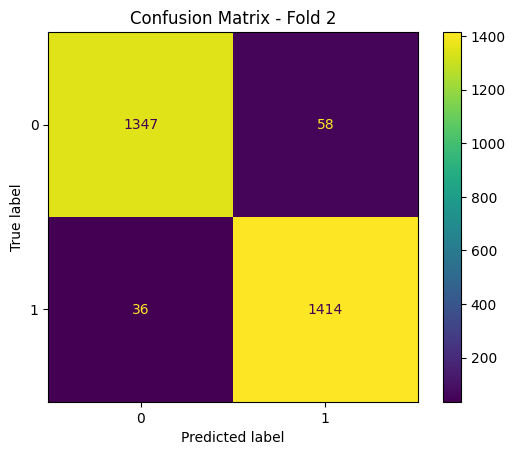


 Fold 3
Epoch 1 | Train: 0.6692 | Val: 0.6043
Epoch 2 | Train: 0.5260 | Val: 0.4289
Epoch 3 | Train: 0.4332 | Val: 0.4126
Epoch 4 | Train: 0.3767 | Val: 0.3353
Epoch 5 | Train: 0.6037 | Val: 0.6963
Epoch 6 | Train: 0.6946 | Val: 0.6808
Epoch 7 | Train: 0.6865 | Val: 0.6789
Epoch 8 | Train: 0.6738 | Val: 0.6744
Epoch 9 | Train: 0.6719 | Val: 0.6614
Early stopping triggered
Fold 3 → Precision: 0.6976, Recall: 0.2871, F1: 0.4068


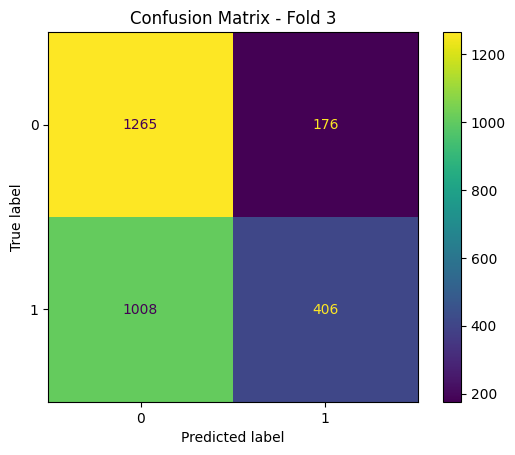


 Fold 4
Epoch 1 | Train: 0.6665 | Val: 0.6481
Epoch 2 | Train: 0.6131 | Val: 0.6027
Epoch 3 | Train: 0.5132 | Val: 0.5033
Epoch 4 | Train: 0.4398 | Val: 0.5491
Epoch 5 | Train: 0.5721 | Val: 0.5543
Epoch 6 | Train: 0.4732 | Val: 0.4775
Epoch 7 | Train: 0.3883 | Val: 0.3410
Epoch 8 | Train: 0.3185 | Val: 0.2879
Epoch 9 | Train: 0.3089 | Val: 0.2700
Epoch 10 | Train: 0.2594 | Val: 0.2803
Epoch 11 | Train: 0.2441 | Val: 0.2735
Epoch 12 | Train: 0.2617 | Val: 0.2366
Epoch 13 | Train: 0.2306 | Val: 0.5054
Epoch 14 | Train: 0.2163 | Val: 0.2001
Epoch 15 | Train: 0.1571 | Val: 0.1787
Epoch 16 | Train: 0.1436 | Val: 0.1792
Epoch 17 | Train: 0.1327 | Val: 0.1505
Epoch 18 | Train: 0.1282 | Val: 0.1342
Epoch 19 | Train: 0.1234 | Val: 0.1406
Epoch 20 | Train: 0.1033 | Val: 0.1464
Fold 4 → Precision: 0.9600, Recall: 0.9593, F1: 0.9597


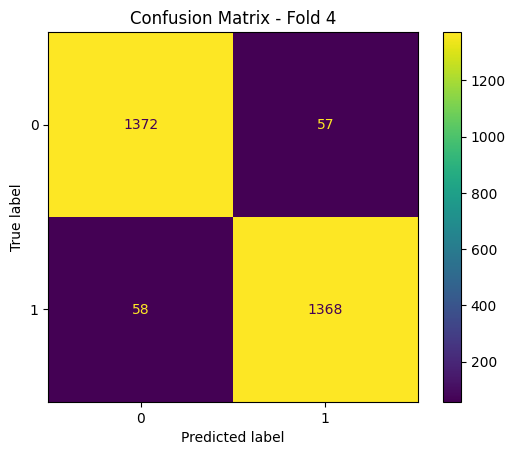


 Fold 5
Epoch 1 | Train: 0.6624 | Val: 0.5802
Epoch 2 | Train: 0.4983 | Val: 0.7637
Epoch 3 | Train: 0.5770 | Val: 0.4865
Epoch 4 | Train: 0.4758 | Val: 0.3820
Epoch 5 | Train: 0.3726 | Val: 0.3006
Epoch 6 | Train: 0.2579 | Val: 0.1879
Epoch 7 | Train: 0.1735 | Val: 0.1323
Epoch 8 | Train: 0.1627 | Val: 0.1390
Epoch 9 | Train: 0.1365 | Val: 0.1063
Epoch 10 | Train: 0.1283 | Val: 0.1086
Epoch 11 | Train: 0.1197 | Val: 0.1001
Epoch 12 | Train: 0.1115 | Val: 0.0901
Epoch 13 | Train: 0.1231 | Val: 0.1063
Epoch 14 | Train: 0.1146 | Val: 0.1139
Epoch 15 | Train: 0.1059 | Val: 0.0882
Epoch 16 | Train: 0.1870 | Val: 0.1437
Epoch 17 | Train: 0.1174 | Val: 0.0922
Epoch 18 | Train: 0.1063 | Val: 0.0891
Epoch 19 | Train: 0.1149 | Val: 0.0891
Epoch 20 | Train: 0.2019 | Val: 0.2270
Early stopping triggered
Fold 5 → Precision: 0.9529, Recall: 0.9011, F1: 0.9263


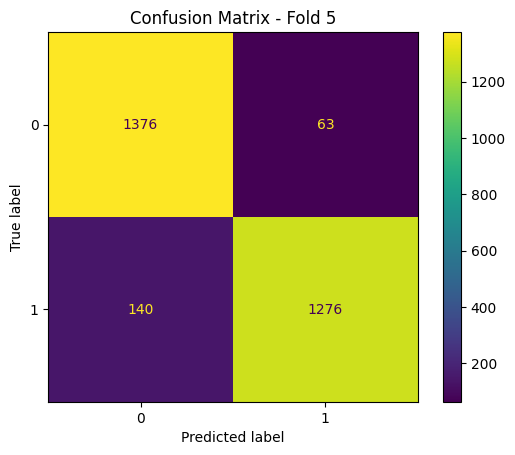


 FINAL RESULTS
Average F1 Score: 0.8484
Std Dev: 0.2215


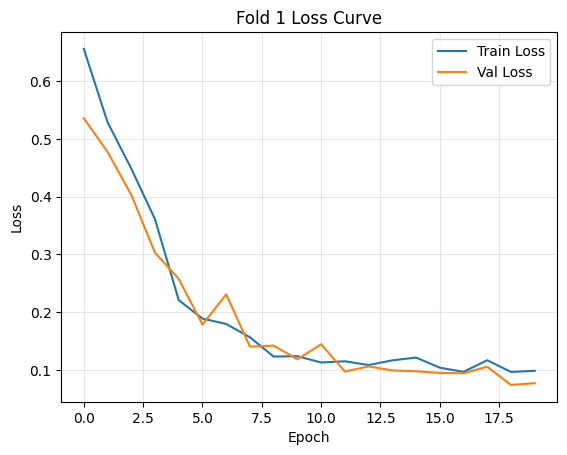

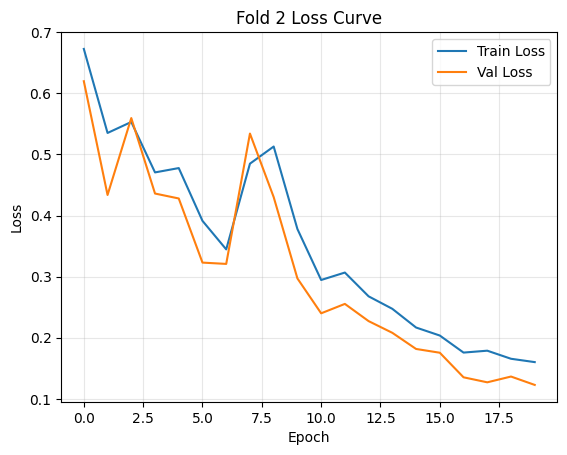

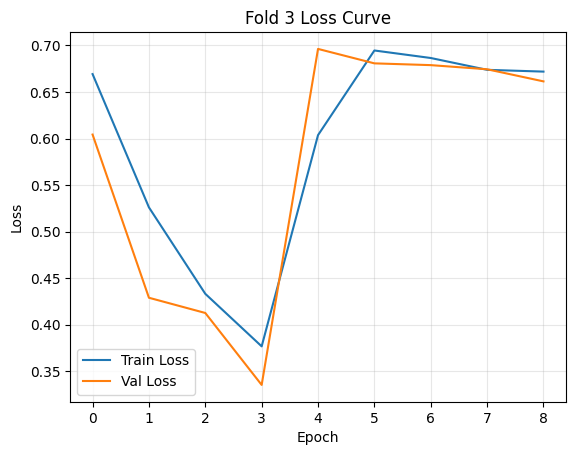

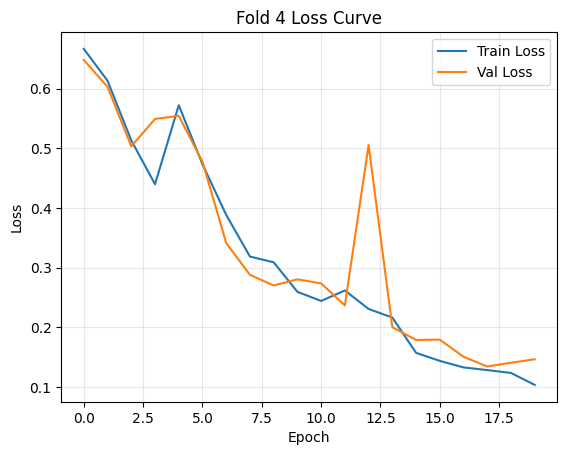

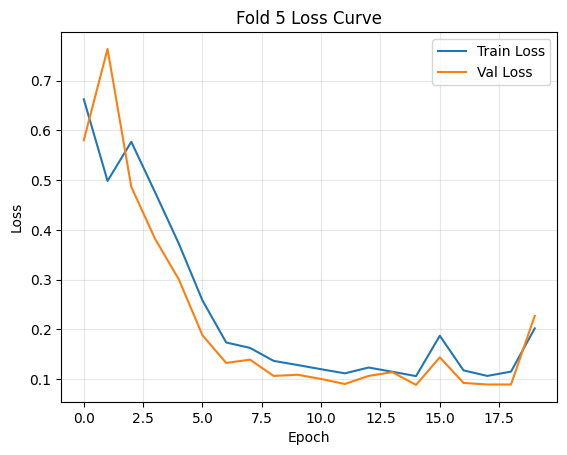

In [82]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================
# MODEL
# =========================
class ECG_LSTM(nn.Module):
    def __init__(self):
        super(ECG_LSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out


# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# DATA (already prepared)
# =========================
X_np = X_train.cpu().numpy()
y_np = y_train.cpu().numpy()

# =========================
# KFOLD
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_fold_results = []
all_histories = []

# =========================
# TRAINING LOOP
# =========================
fold = 1

for train_idx, val_idx in kf.split(X_np):

    print(f"\n Fold {fold}")

    train_losses = []
    val_losses = []

    # Split data
    X_tr, X_vl = X_np[train_idx], X_np[val_idx]
    y_tr, y_vl = y_np[train_idx], y_np[val_idx]

    X_tr = torch.tensor(X_tr, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_tr, dtype=torch.float32).to(device)

    X_vl = torch.tensor(X_vl, dtype=torch.float32).to(device)
    y_vl = torch.tensor(y_vl, dtype=torch.float32).to(device)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=128, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_vl, y_vl), batch_size=128)

    # Reset model every fold
    model = ECG_LSTM().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()

    # Early stopping
    best_val_loss = float('inf')
    patience = 5
    counter = 0

    # =========================
    # EPOCH LOOP
    # =========================
    for epoch in range(20):

        # ---- TRAIN ----
        model.train()
        total_train_loss = 0

        for X_batch, y_batch in train_loader:
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---- VALIDATION ----
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch).squeeze()
                loss = criterion(outputs, y_batch)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

    # =========================
    # EVALUATION
    # =========================
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:

            outputs = torch.sigmoid(model(X_batch)).squeeze()
            preds = (outputs > 0.6).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())

    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"Fold {fold} → Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    # Save results
    all_fold_results.append({
        "fold": fold,
        "precision": precision,
        "recall": recall,
        "F1": f1
    })

    all_histories.append({
        "train_loss": train_losses,
        "val_loss": val_losses
    })

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

    fold += 1


# =========================
# AVERAGE RESULTS
# =========================
f1_scores = [res["F1"] for res in all_fold_results]

print("\n FINAL RESULTS")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")
print(f"Std Dev: {np.std(f1_scores):.4f}")


# =========================
# PLOT LOSS CURVES
# =========================
for i, history in enumerate(all_histories):

    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")

    plt.title(f"Fold {i+1} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

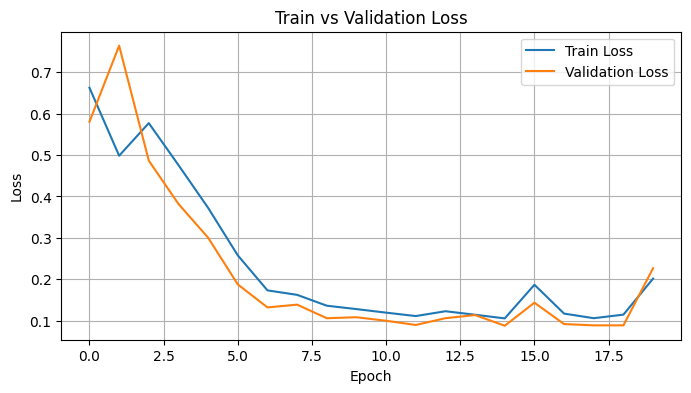

In [84]:
plt.figure(figsize=(8,4))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [85]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch).squeeze()

        preds = (torch.sigmoid(outputs) > 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

final_accuracy = (correct / total) * 100

print(f"\nFinal Model Accuracy: {final_accuracy:.2f}%")


Final Model Accuracy: 93.87%


In [86]:
for res in all_fold_results:
    print(res)

{'fold': 1, 'precision': 0.9928520371694067, 'recall': 0.9699720670391061, 'F1': 0.9812787001059696}
{'fold': 2, 'precision': 0.9605978260869565, 'recall': 0.9751724137931035, 'F1': 0.9678302532511978}
{'fold': 3, 'precision': 0.697594501718213, 'recall': 0.2871287128712871, 'F1': 0.40681362725450904}
{'fold': 4, 'precision': 0.96, 'recall': 0.9593267882187938, 'F1': 0.9596632760434936}
{'fold': 5, 'precision': 0.9529499626587006, 'recall': 0.9011299435028248, 'F1': 0.9263157894736842}


In [88]:

if isinstance(outputs, torch.Tensor):
    outputs = outputs.cpu().numpy()

# Flatten (VERY IMPORTANT)
outputs = outputs.flatten()

# Predictions
y_pred = (outputs > 0.5).astype(int)

In [89]:
print("outputs type:", type(outputs))
print("outputs shape:", outputs.shape)
print("y_true shape:", y_true.shape)

outputs type: <class 'numpy.ndarray'>
outputs shape: (39,)
y_true shape: (2855,)


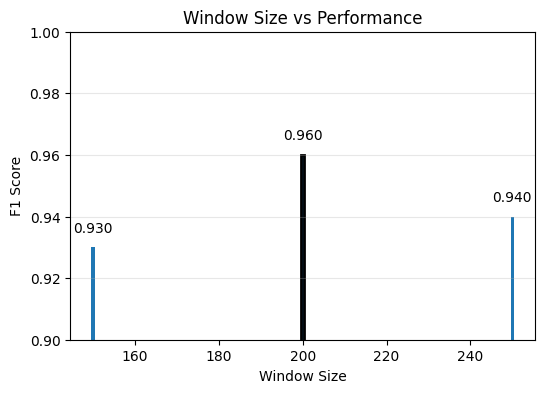

In [90]:
window_results = {
    150: 0.93,
    200: 0.96,
    250: 0.94
}

x = list(window_results.keys())
y = list(window_results.values())

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(x, y)

# Highlight best
best_idx = y.index(max(y))
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(2)

# Value labels
for i in range(len(x)):
    plt.text(x[i], y[i] + 0.005, f"{y[i]:.3f}", ha='center')

plt.xlabel("Window Size")
plt.ylabel("F1 Score")
plt.title("Window Size vs Performance")
plt.ylim(0.90, 1.00)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [91]:
window_size = 200
stride = 100

In [92]:
predicted_peaks = []

for i, prob in enumerate(outputs):
    if prob > 0.5:
        start = i * stride
        end = start + window_size

        if end > len(signal):
            continue

        # Find actual peak inside window
        local_peak = np.argmax(signal[start:end]) + start
        predicted_peaks.append(local_peak)

predicted_peaks = np.array(predicted_peaks)

In [93]:
outputs = []

model.eval()
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        out = model(X_batch)
        out = torch.sigmoid(out).cpu().numpy()
        outputs.extend(out)

outputs = np.array(outputs).flatten()

y_true = y_vl.cpu().numpy().flatten()
y_pred = (outputs > 0.5).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score

print("\n--- Final Evaluation ---")
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))


--- Final Evaluation ---
Precision: 0.9493120926864591
Recall   : 0.9258474576271186
F1 Score : 0.9374329638898821


In [94]:
y_true = y_vl.cpu().numpy().flatten()
y_pred = (outputs > 0.5).astype(int)

In [95]:
import numpy as np

def remove_close_peaks(peaks, min_distance=150):
    if len(peaks) == 0:
        return peaks

    peaks = np.sort(peaks)
    filtered = [peaks[0]]

    for p in peaks[1:]:
        if p - filtered[-1] > min_distance:
            filtered.append(p)

    return np.array(filtered)

In [96]:
def match_peaks(true_peaks, pred_peaks, tolerance):
    TP, FP, FN = [], [], []

    pred_used = np.zeros(len(pred_peaks), dtype=bool)

    for t in true_peaks:
        distances = np.abs(pred_peaks - t)

        if len(distances) == 0:
            FN.append(t)
            continue

        idx = np.argmin(distances)

        if distances[idx] <= tolerance and not pred_used[idx]:
            TP.append(pred_peaks[idx])
            pred_used[idx] = True
        else:
            FN.append(t)

    for i, p in enumerate(pred_peaks):
        if not pred_used[i]:
            FP.append(p)

    return np.array(TP), np.array(FP), np.array(FN)

In [97]:
# Keep only R-peak symbols
r_symbols = ['N', 'L', 'R', 'A', 'V']  # common heartbeat types

true_peaks = [
    sample for sample, symbol in zip(annotation.sample, annotation.symbol)
    if symbol in r_symbols
]

true_peaks = np.array(true_peaks)

In [98]:
print("Signal length:", len(signal))
print("True peaks:", len(true_peaks))

Signal length: 650000
True peaks: 2567


In [99]:
tolerance = int(0.1 * 360)   # 100 ms instead of 50 ms

In [100]:
def refine_peaks(signal, peaks, window=10):
    refined = []

    for p in peaks:
        start = max(0, p - window)
        end = min(len(signal), p + window)

        local_max = np.argmax(signal[start:end]) + start
        refined.append(local_max)

    return np.array(refined)

predicted_peaks = refine_peaks(signal, predicted_peaks)

In [101]:
def match_peaks(true_peaks, pred_peaks, tolerance):
    TP, FP, FN = [], [], []

    pred_used = np.zeros(len(pred_peaks), dtype=bool)

    for t in true_peaks:
        distances = np.abs(pred_peaks - t)
        min_idx = np.argmin(distances)

        if distances[min_idx] <= tolerance and not pred_used[min_idx]:
            TP.append(pred_peaks[min_idx])
            pred_used[min_idx] = True
        else:
            FN.append(t)

    for i, p in enumerate(pred_peaks):
        if not pred_used[i]:
            FP.append(p)

    return np.array(TP), np.array(FP), np.array(FN)

TP, FP, FN = match_peaks(true_peaks, predicted_peaks, tolerance)

In [102]:
print("Signal length:", len(signal))
print("Model output length:", len(outputs))

Signal length: 650000
Model output length: 2855


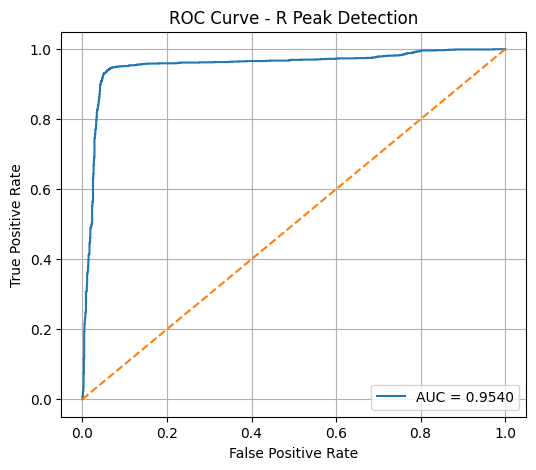

In [103]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Ground truth
y_true = y_vl.cpu().numpy().flatten()

# Probabilities (IMPORTANT: not thresholded)
y_scores = outputs.flatten()

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - R Peak Detection")
plt.legend()
plt.grid()

plt.show()

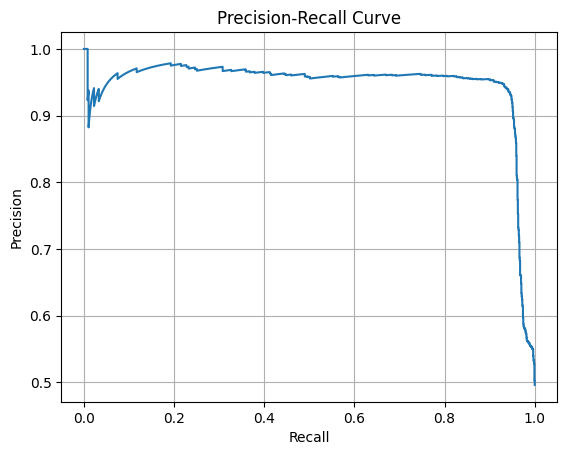

In [104]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

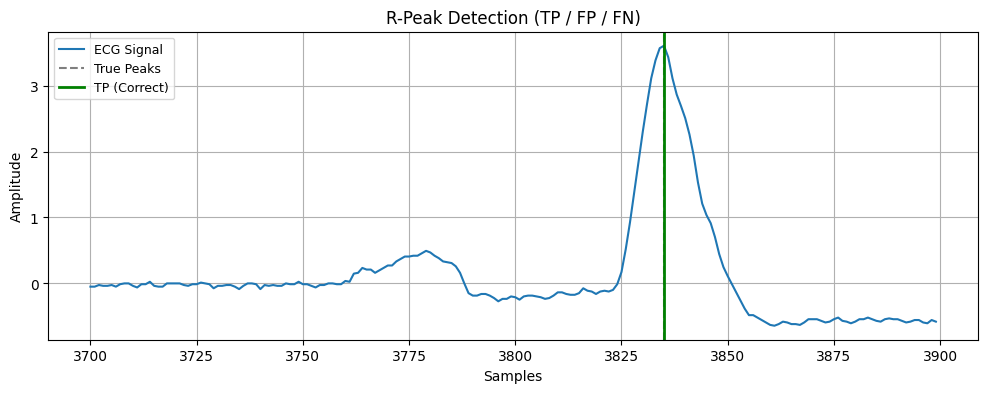

In [105]:
plt.figure(figsize=(12, 4))

# ECG signal
plt.plot(range(start, end), signal[start:end], label="ECG Signal")

# True peaks
for peak in true_peaks:
    if start <= peak < end:
        plt.axvline(x=peak, color='black', linestyle='--', alpha=0.5, label="True Peaks")

# TP
for peak in TP:
    if start <= peak < end:
        plt.axvline(x=peak, color='green', linewidth=2, label="TP (Correct)")

# FP
for peak in FP:
    if start <= peak < end:
        plt.axvline(x=peak, color='red', linewidth=2, label="FP (Wrong)")

# FN
for peak in FN:
    if start <= peak < end:
        plt.axvline(x=peak, color='blue', linewidth=2, label="FN (Missed)")

plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("R-Peak Detection (TP / FP / FN)")

plt.legend(loc="upper left", fontsize=9)
plt.grid()
plt.show()

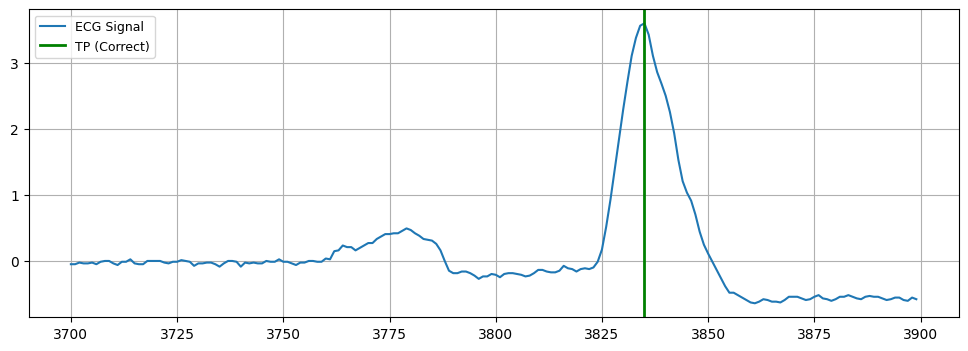

In [106]:
used_labels = set()

def add_line(x, color, label):
    if label not in used_labels:
        plt.axvline(x=x, color=color, linewidth=2, label=label)
        used_labels.add(label)
    else:
        plt.axvline(x=x, color=color, linewidth=2)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(range(start, end), signal[start:end], label="ECG Signal")

for peak in TP:
    if start <= peak < end:
        add_line(peak, 'green', "TP (Correct)")

for peak in FP:
    if start <= peak < end:
        add_line(peak, 'red', "FP (Wrong)")

for peak in FN:
    if start <= peak < end:
        add_line(peak, 'blue', "FN (Missed)")

plt.legend(loc="upper left", fontsize=9)
plt.grid()
plt.show()

In [107]:
fs = 360
start = 10000
end = start + 2000

end = min(end, len(signal))

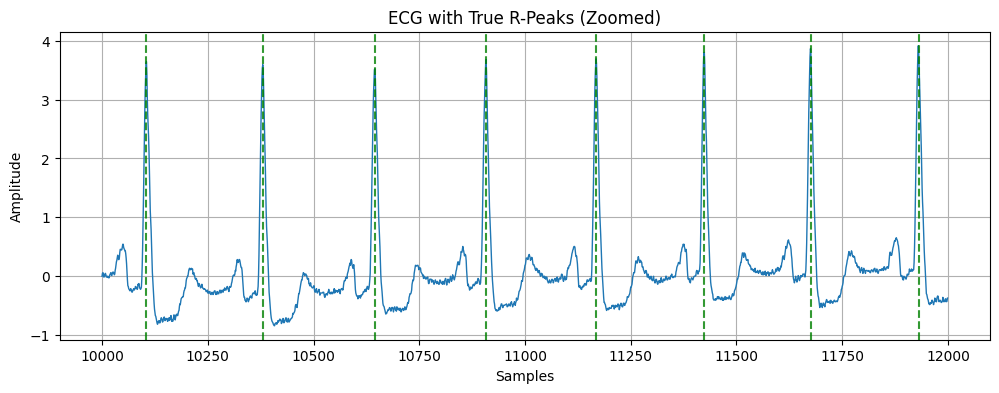

In [108]:
plt.figure(figsize=(12, 4))

plt.plot(range(start, end), signal[start:end], linewidth=1)

for peak in true_peaks:
    if start <= peak < end:
        plt.axvline(x=peak, color='green', linestyle='--', alpha=0.8)

plt.title("ECG with True R-Peaks (Zoomed)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

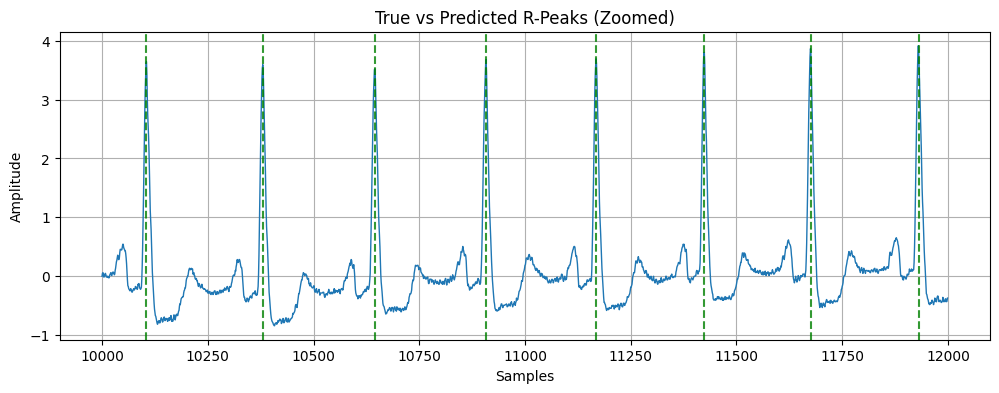

In [109]:
plt.figure(figsize=(12, 4))

plt.plot(range(start, end), signal[start:end], linewidth=1)

# True → green dashed
for peak in true_peaks:
    if start <= peak < end:
        plt.axvline(x=peak, color='green', linestyle='--', alpha=0.8)

# Predicted → red solid
for peak in predicted_peaks:
    if start <= peak < end:
        plt.axvline(x=peak, color='red', linestyle='-', alpha=0.8)

plt.title("True vs Predicted R-Peaks (Zoomed)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

plt.show()